In [49]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
from matplotlib import pyplot as plt

sys.path.insert(0, os.path.abspath("../.."))

from AML_BRATS.data.data_loading import get_dataset_folds, BRATSDataset
from AML_BRATS.models.train_unet import UNet
from AML_BRATS.models.metrics import calculate_dice, calculate_precision, calculate_recall

folds, _ = get_dataset_folds(
    "../../data/BraTS2020_training_data/content/data/meta_data.csv"
)


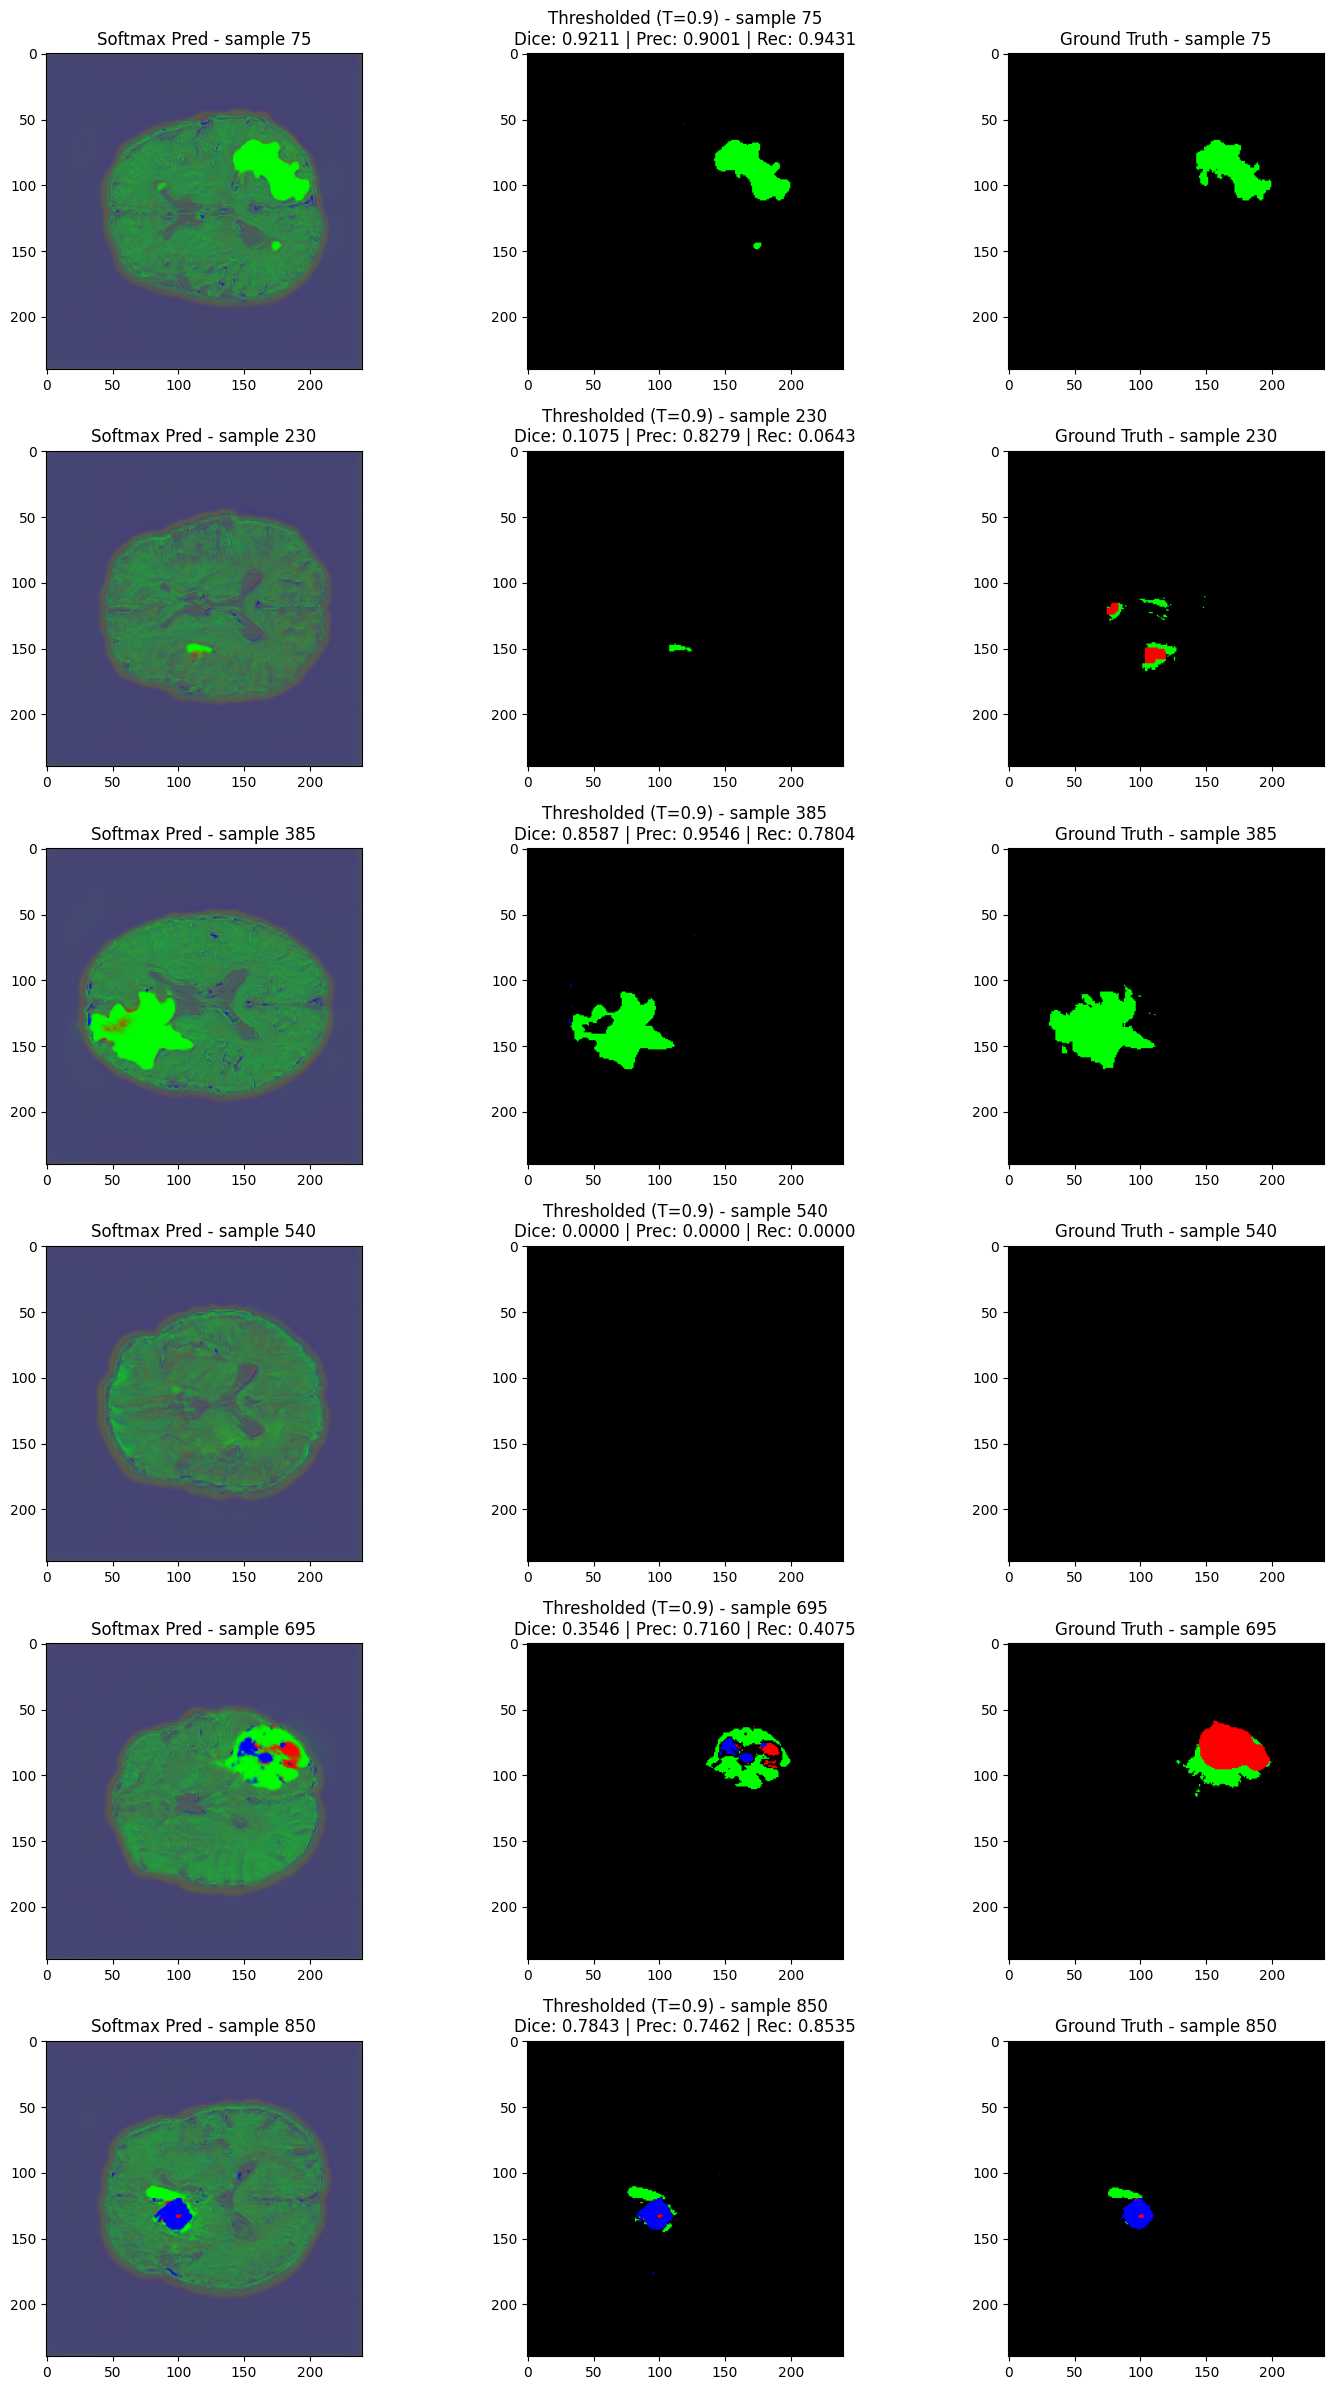

In [ ]:
fold1_val = folds[0][1]
inputs = fold1_val[:]
ds = BRATSDataset(inputs, base_path=Path("../.."))

model = UNet(3, True)
# MODEL_NAME = (
#     "UNET_HYD_25EPOCHS_adam_BNORM_LR0.0001_WD0.01_bce1_NOAUG_BS64_FOLD1"
# )  # PRETTY GOOD
MODEL_NAME = (
    "UNET_HYD_12EPOCHS_adam_BNORM_LR0.0001_WD0.01_bce1_BS64_FOLD1"
)  # BETTER?
model.load_state_dict(
    torch.load(f"../../models/{MODEL_NAME}_final.pkl", weights_only=True)
)
model.eval()

sample_indices = [2, 7, 15, 23, 31, 42, 50, 61, 74, 88]
sample_indices = list(range(75, 1000, 155))
# Threshold value for binary predictions
THRESHOLD = 0.9
fig, axes = plt.subplots(
    len(sample_indices), 3, figsize=(15, 4 * len(sample_indices))
)
for row, sample_index in enumerate(sample_indices):
    data = ds[sample_index]
    im = torch.from_numpy(data["image"]).unsqueeze(0)
    mask = np.moveaxis(data["mask"], 0, -1)
    with torch.no_grad():
        output = model(im)
    rgb = output[0].softmax(dim=0).permute(1, 2, 0).cpu().numpy()
    
    # Apply thresholding per channel to get binary RGB
    thresholded_rgb = (rgb > THRESHOLD).astype(float)
    
    # Compute Dice score between thresholded prediction and ground truth
    thresholded_tensor = torch.from_numpy(thresholded_rgb).unsqueeze(0)  # B=1, H, W, C
    thresholded_tensor = thresholded_tensor.permute(0, 3, 1, 2)  # B, C, H, W
    mask_tensor = torch.from_numpy(mask).unsqueeze(0).permute(0, 3, 1, 2).float()  # B, C, H, W
    dice_score = float(calculate_dice(thresholded_tensor, mask_tensor).item())

    # Compute precision and recall using metrics functions (handles masking and smoothing)
    precision_mean = float(calculate_precision(thresholded_tensor, mask_tensor).item())
    recall_mean = float(calculate_recall(thresholded_tensor, mask_tensor).item())
    # precision_mean = 0
    # recall_mean = 0

    # Display softmax prediction
    axes[row, 0].imshow(rgb[:, :, :])
    axes[row, 0].set_title(f"Softmax Pred - sample {sample_index}")
    
    # Display thresholded prediction as binary RGB
    axes[row, 1].imshow(thresholded_rgb)
    axes[row, 1].set_title(f"Thresholded (T={THRESHOLD}) - sample {sample_index}\nDice: {dice_score:.4f} | Prec: {precision_mean:.4f} | Rec: {recall_mean:.4f}")

    # Display ground truth mask
    axes[row, 2].imshow(mask)
    axes[row, 2].set_title(f"Ground Truth - sample {sample_index}")

plt.tight_layout()
